In [1]:
#import various useful packages
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
import pandas as pd
%matplotlib inline

#importing dimensionality reduction packages
from sklearn.decomposition import PCA
from sklearn.decomposition import NMF
from sklearn.manifold import MDS
from sklearn.manifold import Isomap 
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import TSNE
# import umap

#importing clustering packages
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

/Users/pgmenon/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import pandas as pd

df = pd.read_csv("spike_data.csv", header=None)
print(df.shape)
df.head()

(3636, 34)


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,1687.40,1697.70,1085.0,792.40,1274.50,527.26,-4827.7,-15553.0,-27374.0,-33711.0,...,17661.0,16239.0,14269.0,11916.0,10035.0,9098.8,8325.90,6416.30,3121.00,-353.94
1,-518.44,-227.55,-1056.1,-1818.80,-1486.20,-1840.20,-6738.2,-17663.0,-30531.0,-38216.0,...,17821.0,17867.0,17582.0,16649.0,15344.0,14182.0,13126.00,11704.00,9837.50,8074.00
2,372.62,-545.55,-1721.7,-2910.60,-3609.20,-3838.30,-4207.1,-5112.2,-6163.2,-6635.3,...,-4047.5,-4007.8,-3810.6,-3281.6,-2386.5,-1380.9,-684.59,-517.98,-655.99,-604.69
3,182.17,-357.40,-1115.5,-1196.30,-1233.00,-4198.00,-12708.0,-25130.0,-35357.0,-37512.0,...,13373.0,12099.0,10839.0,9600.7,8615.3,7861.6,6967.00,5724.70,4409.60,3385.00
4,2857.90,2945.90,2132.3,796.86,-469.78,-1601.30,-3132.4,-5342.9,-7465.9,-8074.7,...,3261.4,2721.9,2783.5,3068.3,2963.1,2322.3,1579.50,1189.70,1174.70,1294.30


In [3]:
spike_data = df.to_numpy()
print(np.shape(spike_data))


(3636, 34)


# Unsupervised clustering


In [4]:
#  TSNE for unsupervised clustering of the time-series series in a 2D space 
listRand = []
for i in range(200):
  listRand.append(random.randint(0,np.shape(spike_data)[0]))

Text(0.5, 1.0, 'TSNE')

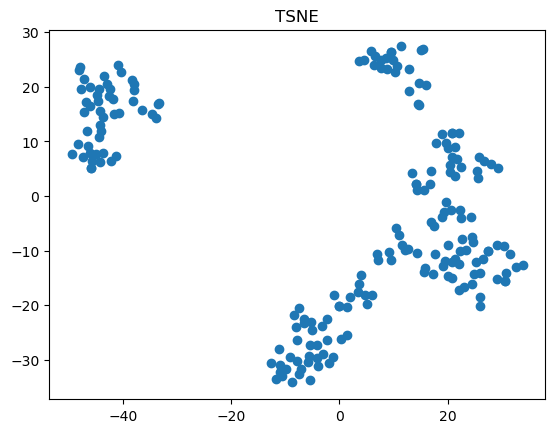

In [5]:
#T-SNE
digit_tsne = TSNE(n_components=2,perplexity=10,method='exact') 

tsne_projections = digit_tsne.fit_transform(spike_data[listRand,:])
plt.scatter(tsne_projections[:,0],tsne_projections[:,1]) #,c=Names,edgecolor="none",cmap=plt.cm.get_cmap('nipy_spectral'));plt.colorbar()
plt.title('TSNE')



<ipython-input-6-bf8119ddd880>:22: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ax.add_patch(Ellipse(position, nsig * width, nsig * height,


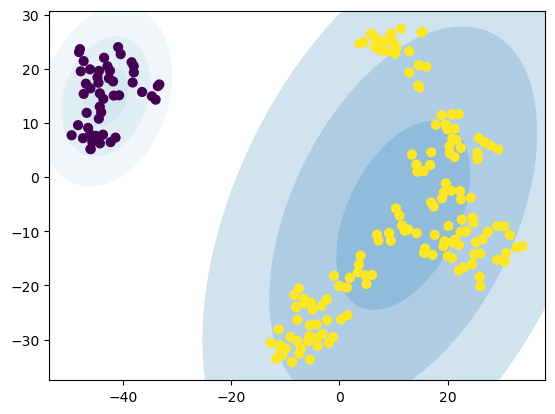

In [6]:
# Fit k=2 Gaussians to the TSNE reduced dimensional space in 2D

k = 2

from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Draw the Ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle, **kwargs))
       
def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    ax.axis('equal')
    
    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, alpha=w * w_factor)


Y2 = tsne_projections
gmm_example = GaussianMixture(n_components=k).fit(Y2[:,:2])
gmm_labels = gmm_example.predict(Y2)
gmm_probs = gmm_example.predict_proba(Y2)
plot_gmm(gmm_example, Y2)

In [7]:
len(gmm_labels)

200

# LDA on the TSNE reduced space of the 34-dimensional time-series inputs


In [43]:
y = gmm_labels
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(tsne_projections, y, test_size = 0.3, random_state = 0)

In [44]:
X_train.shape

(140, 2)

In [45]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components = 1)
X_train1 = lda.fit_transform(X_train, y_train)
X_test1 = lda.transform(X_test)


In [46]:
# spikeDataLDA_direct = lda.fit_transform(spike_data[listRand,:], gmm_labels)
# spikeDataLDA_direct_projection = lda.transform(spikeDataLDA_direct)

In [47]:
X_train1.shape

(140, 1)

In [48]:
import time
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(penalty='l2', solver='sag', C=1)
start_time = time.time()
fit2 = classifier.fit(X_train1, y_train)
end_time = time.time()
time3 = end_time-start_time
print(time3)


0.004217863082885742


In [49]:
y_pred = fit2.predict(X_test1)

In [50]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(cm)
print(cr)


[[49  0]
 [ 0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        11

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



Text(0.5, 1.0, 'ROC curve')

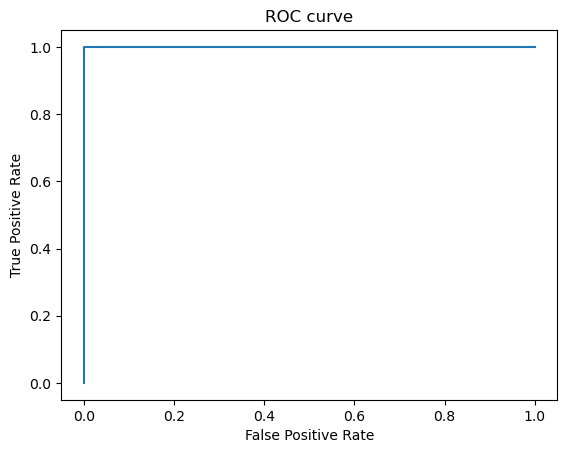

In [51]:
# Make an ROC curve of the test data
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, fit2.predict_proba(X_test1)[:,1])

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')



# Instead of doing LDA on TSNE reduced space, lets try doing it on the original data

In [58]:
#  TSNE for unsupervised clustering of the time-series series in a 2D space 
listRand2 = []
for i in range(200):
  listRand2.append(random.randint(0,np.shape(spike_data)[0]))

In [59]:
X = spike_data[listRand2,:]
y = gmm_labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

lda = LDA(n_components = 1)
X_train1 = lda.fit_transform(X_train, y_train)
X_test1 = lda.transform(X_test)


In [60]:
import time
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(penalty='l2', solver='sag', C=1)
start_time = time.time()
fit2 = classifier.fit(X_train1, y_train)
end_time = time.time()
time3 = end_time-start_time
print(time3)


0.0038688182830810547


In [61]:
fit2.predict_proba(X_test1)[:,1]

array([0.37387008, 0.19269097, 0.21827828, 0.08955828, 0.14267255,
       0.20138854, 0.0764193 , 0.12871732, 0.02611387, 0.11477708,
       0.16578922, 0.28813108, 0.18490444, 0.59396235, 0.22252558,
       0.18161732, 0.56036315, 0.20591321, 0.14023799, 0.69011168,
       0.6944574 , 0.03990141, 0.03362615, 0.17825957, 0.20682312,
       0.46159429, 0.11964034, 0.23451363, 0.27317412, 0.53206036,
       0.05093505, 0.15219626, 0.16893589, 0.49450706, 0.22626622,
       0.03139096, 0.12728031, 0.98988992, 0.31390579, 0.13928752,
       0.07588346, 0.02704812, 0.98831838, 0.21487957, 0.39077415,
       0.43316205, 0.25460696, 0.79203058, 0.15734405, 0.27896325,
       0.06129509, 0.22024061, 0.32163476, 0.41498941, 0.10046563,
       0.03493681, 0.72167018, 0.21367381, 0.32149396, 0.03544669])

In [67]:
y_pred =  fit2.predict_proba(X_test1)[:,1] >= 0.2 #fit2.predict(X_test1)

cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(cm)
print(cr)


[[26 23]
 [ 2  9]]
              precision    recall  f1-score   support

           0       0.93      0.53      0.68        49
           1       0.28      0.82      0.42        11

    accuracy                           0.58        60
   macro avg       0.60      0.67      0.55        60
weighted avg       0.81      0.58      0.63        60



Text(0.5, 1.0, 'ROC curve')

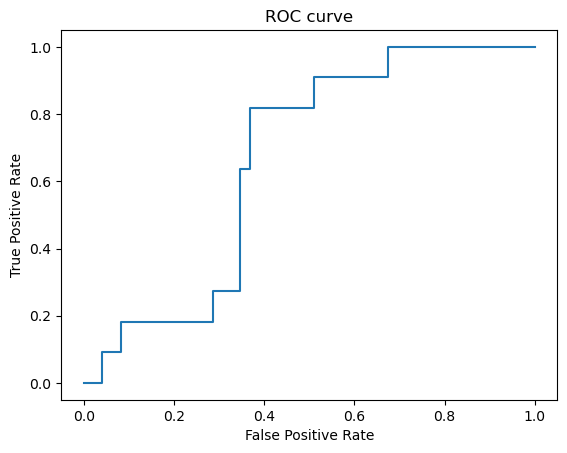

In [63]:
# Make an ROC curve of the test data
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, fit2.predict_proba(X_test1)[:,1])

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')

